# Embedded Interpolants

Each experiment: **FIT** (learn velocity chain) then **GENERATE** (fresh samples).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import sys
sys.path.insert(0, '..')
from src import EmbeddedInterpolants, sliced_wasserstein1, distributions

np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 130

def sw1(X, Y):
    X = X.reshape(-1, X.shape[-1]) if X.ndim > 1 else X.reshape(-1,1)
    Y = Y.reshape(-1, Y.shape[-1]) if Y.ndim > 1 else Y.reshape(-1,1)
    return sliced_wasserstein1(X, Y)

---
## 1. R¹: Gaussian → Bimodal

In [ ]:
N_train, N_data, N_new = 600, 300, 800
X1 = distributions.two_modes_1d(N_data, mu=2.5, sigma=0.5).reshape(-1,1)
x_true = distributions.two_modes_1d(N_new, mu=2.5, sigma=0.5).reshape(-1,1)

model_1d = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-9, K_steps=80, N_src_max=10000, n_inducing=100, noise_level=1.0, rescale=True, q = 0.5, q_final=0.1)
print('FIT:'); model_1d.fit(np.random.randn(N_train,1), X1, n_iterations=6)
print('\nTRANSPORT:'); res_1d = model_1d.transport(np.random.randn(N_new,1), verbose=True)

sw_t1 = [sw1(s, x_true) for s in model_1d._fit_result['snapshots']]
sw_n1 = [sw1(s, x_true) for s in res_1d['snapshots']]
print(f'\nTrain SW1={sw_t1[-1]:.3f}, New SW1={sw_n1[-1]:.3f}')

FIT:
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=1.7484
  Iter 1: lift_ratio=0.552,  gamma=0.01000,  q=0.500,  sigma=1.748,  M=100
  Iter 2: lift_ratio=0.552,  gamma=0.00800,  q=0.420,  sigma=1.423,  M=100
  Iter 3: lift_ratio=0.517,  gamma=0.00600,  q=0.340,  sigma=1.114,  M=100
  Iter 4: lift_ratio=0.429,  gamma=0.00400,  q=0.260,  sigma=0.828,  M=100
  Iter 5: lift_ratio=0.419,  gamma=0.00200,  q=0.180,  sigma=0.560,  M=100
  Iter 6: lift_ratio=0.375,  gamma=0.00000,  q=0.100,  sigma=0.307,  M=100

TRANSPORT:
  Iter 1: lift_ratio=0.567
  Iter 2: lift_ratio=0.567
  Iter 3: lift_ratio=0.525
  Iter 4: lift_ratio=0.430
  Iter 5: lift_ratio=0.415
  Iter 6: lift_ratio=0.375

Train SW1=0.150, New SW1=0.118


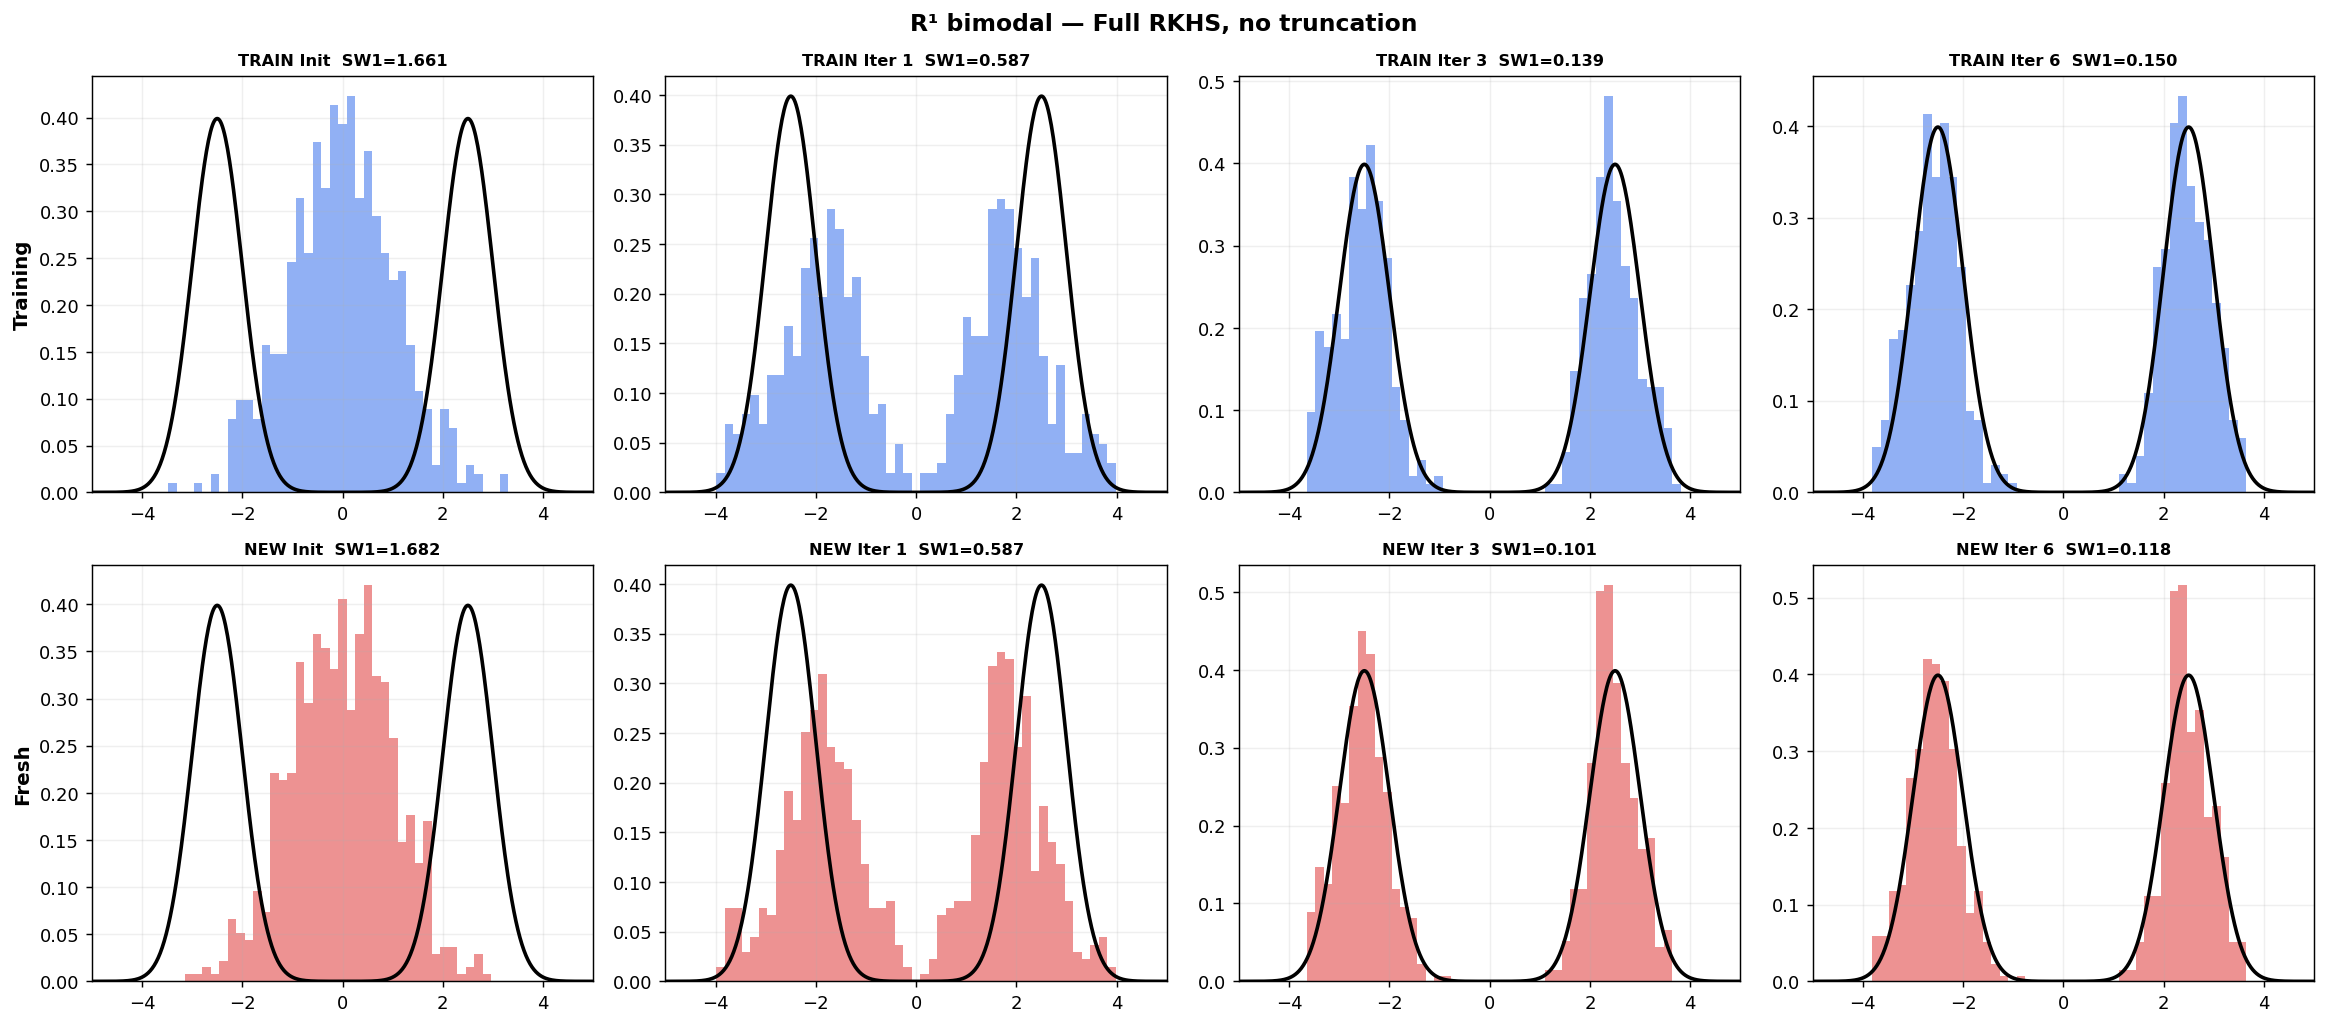

In [13]:
xd = np.linspace(-5,5,500)
rho = 0.5/(0.5*np.sqrt(2*np.pi))*(np.exp(-(xd-2.5)**2/0.5)+np.exp(-(xd+2.5)**2/0.5))
bins = np.linspace(-5,5,60)
fig, axes = plt.subplots(2, 4, figsize=(18,8))
for col, it in enumerate([0,1,3,6]):
    ax = axes[0,col]
    ax.hist(model_1d._fit_result['snapshots'][it][:,0], bins=bins, density=True, alpha=0.5, color='#2563eb')
    ax.plot(xd,rho,'k-',lw=2); lab='Init' if it==0 else f'Iter {it}'
    ax.set_title(f'TRAIN {lab}  SW1={sw_t1[it]:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlim(-5,5); ax.grid(True,alpha=0.2)
    if col==0: ax.set_ylabel('Training', fontsize=11, fontweight='bold')
    ax = axes[1,col]
    ax.hist(res_1d['snapshots'][it][:,0], bins=bins, density=True, alpha=0.5, color='#dc2626')
    ax.plot(xd,rho,'k-',lw=2)
    ax.set_title(f'NEW {lab}  SW1={sw_n1[it]:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlim(-5,5); ax.grid(True,alpha=0.2)
    if col==0: ax.set_ylabel('Fresh', fontsize=11, fontweight='bold')
fig.suptitle('R¹ bimodal — Full RKHS, no truncation', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

---
## 2. R² — 3 Modes (Triangle)

In [27]:
N_train, N_data, N_new = 500, 250, 600
X1_2d = distributions.three_modes_2d(N_data)
x_true_2d = distributions.three_modes_2d(N_new)

model_2d = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-9, K_steps=80, N_src_max=10000, n_inducing=100, noise_level=1.5, q=0.5, q_final=0.1)
print('FIT:'); model_2d.fit(np.random.randn(N_train,2), X1_2d, n_iterations=10)
print('\nTRANSPORT:'); res_2d = model_2d.transport(np.random.randn(N_new,2), verbose=True)

sw_t2 = [sw1(s, x_true_2d) for s in model_2d._fit_result['snapshots']]
sw_n2 = [sw1(s, x_true_2d) for s in res_2d['snapshots']]
print(f'\nTrain SW1={sw_t2[-1]:.3f}, New SW1={sw_n2[-1]:.3f}')

FIT:
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=2.2518
  Iter 1: lift_ratio=0.476,  gamma=0.01000,  q=0.500,  sigma=2.252,  M=100
  Iter 2: lift_ratio=0.477,  gamma=0.00889,  q=0.456,  sigma=2.108,  M=100
  Iter 3: lift_ratio=0.481,  gamma=0.00778,  q=0.411,  sigma=1.960,  M=100
  Iter 4: lift_ratio=0.476,  gamma=0.00667,  q=0.367,  sigma=1.813,  M=100
  Iter 5: lift_ratio=0.452,  gamma=0.00556,  q=0.322,  sigma=1.663,  M=100
  Iter 6: lift_ratio=0.405,  gamma=0.00444,  q=0.278,  sigma=1.507,  M=100
  Iter 7: lift_ratio=0.351,  gamma=0.00333,  q=0.233,  sigma=1.343,  M=100
  Iter 8: lift_ratio=0.322,  gamma=0.00222,  q=0.189,  sigma=1.174,  M=100
  Iter 9: lift_ratio=0.314,  gamma=0.00111,  q=0.144,  sigma=0.989,  M=100
  Iter 10: lift_ratio=0.286,  gamma=0.00000,  q=0.100,  sigma=0.790,  M=100

TRANSPORT:
  Iter 1: lift_ratio=0.480
  Iter 2: lift_ratio=0.480
  Iter 3: lift_ratio=0.479
  Iter 4: lift_ratio=0.478
  Iter 5: lift_ratio=0.450
  Iter 6: lift_ratio=0.404
  Iter 

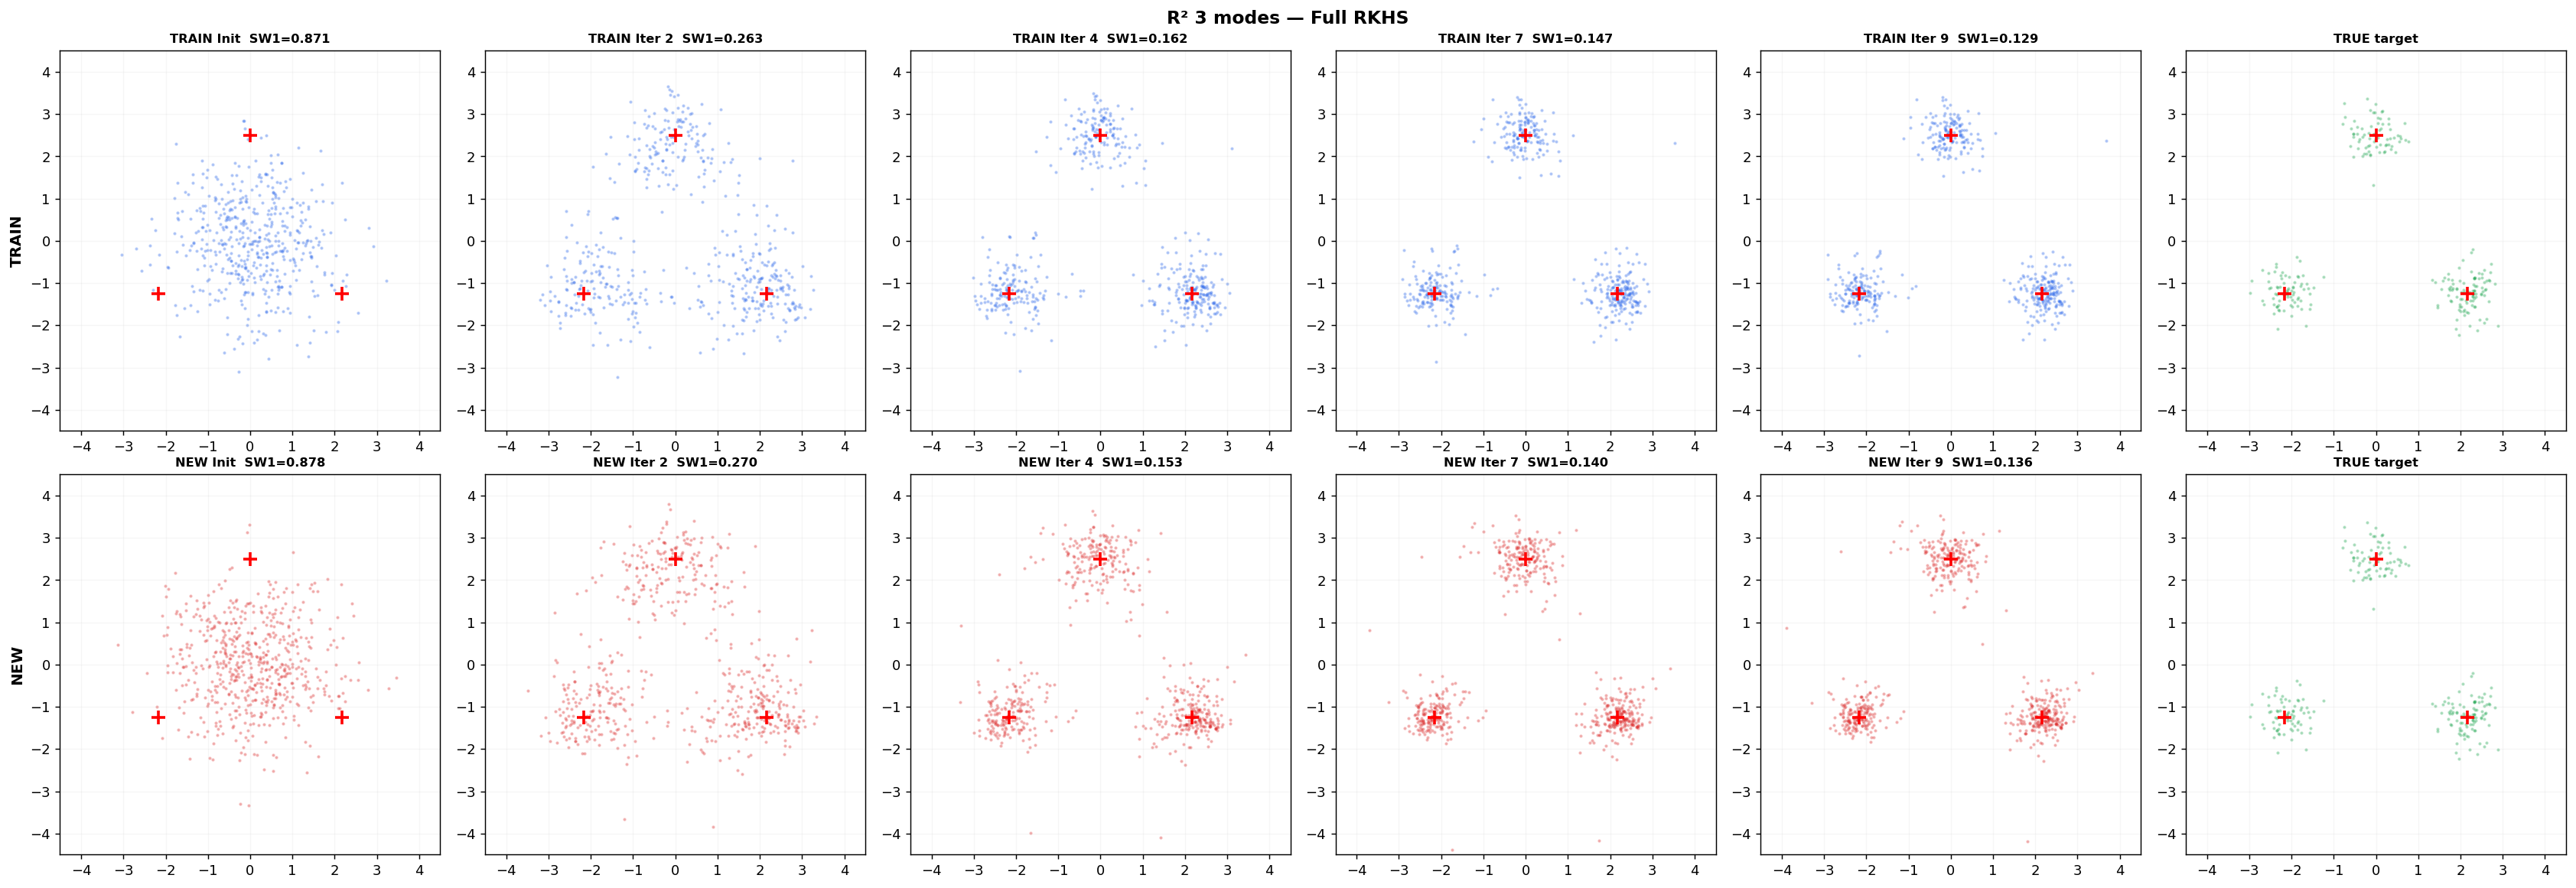

In [28]:
angles_3 = np.array([np.pi/2, np.pi/2+2*np.pi/3, np.pi/2+4*np.pi/3])
centers_3 = 2.5*np.column_stack([np.cos(angles_3), np.sin(angles_3)])

fig, axes = plt.subplots(2, 6, figsize=(26,9))
for col, it in enumerate([0, 2, 4, 7, 9]):
    for row, (sn,c,sv,lb) in enumerate([
        (model_2d._fit_result['snapshots'],'#2563eb',sw_t2,'TRAIN'),
        (res_2d['snapshots'],'#dc2626',sw_n2,'NEW')]):
        ax = axes[row,col]; ax.scatter(sn[it][:,0],sn[it][:,1],s=2,alpha=0.25,c=c)
        for cc in centers_3: ax.plot(cc[0],cc[1],'r+',ms=10,mew=2)
        itl = 'Init' if it==0 else f'Iter {it}'
        ax.set_title(f'{lb} {itl}  SW1={sv[it]:.3f}', fontsize=9, fontweight='bold')
        ax.set_xlim(-4.5,4.5); ax.set_ylim(-4.5,4.5); ax.set_aspect('equal'); ax.grid(True,alpha=0.1)
        if col==0: ax.set_ylabel(lb, fontsize=11, fontweight='bold')

for row in (0, 1):
    ax = axes[row, 5]
    ax.scatter(X1_2d[:,0], X1_2d[:,1], s=2, alpha=0.25, c='#16a34a')
    for cc in centers_3: ax.plot(cc[0],cc[1],'r+',ms=10,mew=2)
    ax.set_title('TRUE target', fontsize=9, fontweight='bold')
    ax.set_xlim(-4.5,4.5); ax.set_ylim(-4.5,4.5); ax.set_aspect('equal'); ax.grid(True,alpha=0.1)

fig.suptitle('R² 3 modes — Full RKHS', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

---
## 3. R³ — 4 Modes (Tetrahedron)

In [25]:
N_train, N_data, N_new = 500, 250, 600
X1_3d = distributions.four_modes_3d(N_data)
x_true_3d = distributions.four_modes_3d(N_new)
model_3d = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=0.001, K_steps=80, N_src_max=10000, q=0.5, q_final=0.1, noise_level=1.0)
print('FIT:'); model_3d.fit(np.random.randn(N_train,3), X1_3d, n_iterations=6)
print('\nTRANSPORT:'); res_3d = model_3d.transport(np.random.randn(N_new,3), verbose=True)
sw_t3 = [sw1(s, x_true_3d) for s in model_3d._fit_result['snapshots']]
sw_n3 = [sw1(s, x_true_3d) for s in res_3d['snapshots']]
print(f'\nTrain SW1={sw_t3[-1]:.3f}, New SW1={sw_n3[-1]:.3f}')

FIT:
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=2.6210
  Iter 1: lift_ratio=0.455,  gamma=0.01000,  q=0.500,  sigma=2.621,  M=500
  Iter 2: lift_ratio=0.456,  gamma=0.00820,  q=0.420,  sigma=2.376,  M=500
  Iter 3: lift_ratio=0.474,  gamma=0.00640,  q=0.340,  sigma=2.125,  M=500
  Iter 4: lift_ratio=0.466,  gamma=0.00460,  q=0.260,  sigma=1.864,  M=500
  Iter 5: lift_ratio=0.417,  gamma=0.00280,  q=0.180,  sigma=1.570,  M=500
  Iter 6: lift_ratio=0.361,  gamma=0.00100,  q=0.100,  sigma=1.204,  M=500

TRANSPORT:
  Iter 1: lift_ratio=0.452
  Iter 2: lift_ratio=0.451
  Iter 3: lift_ratio=0.462
  Iter 4: lift_ratio=0.458
  Iter 5: lift_ratio=0.412
  Iter 6: lift_ratio=0.356

Train SW1=0.062, New SW1=0.075


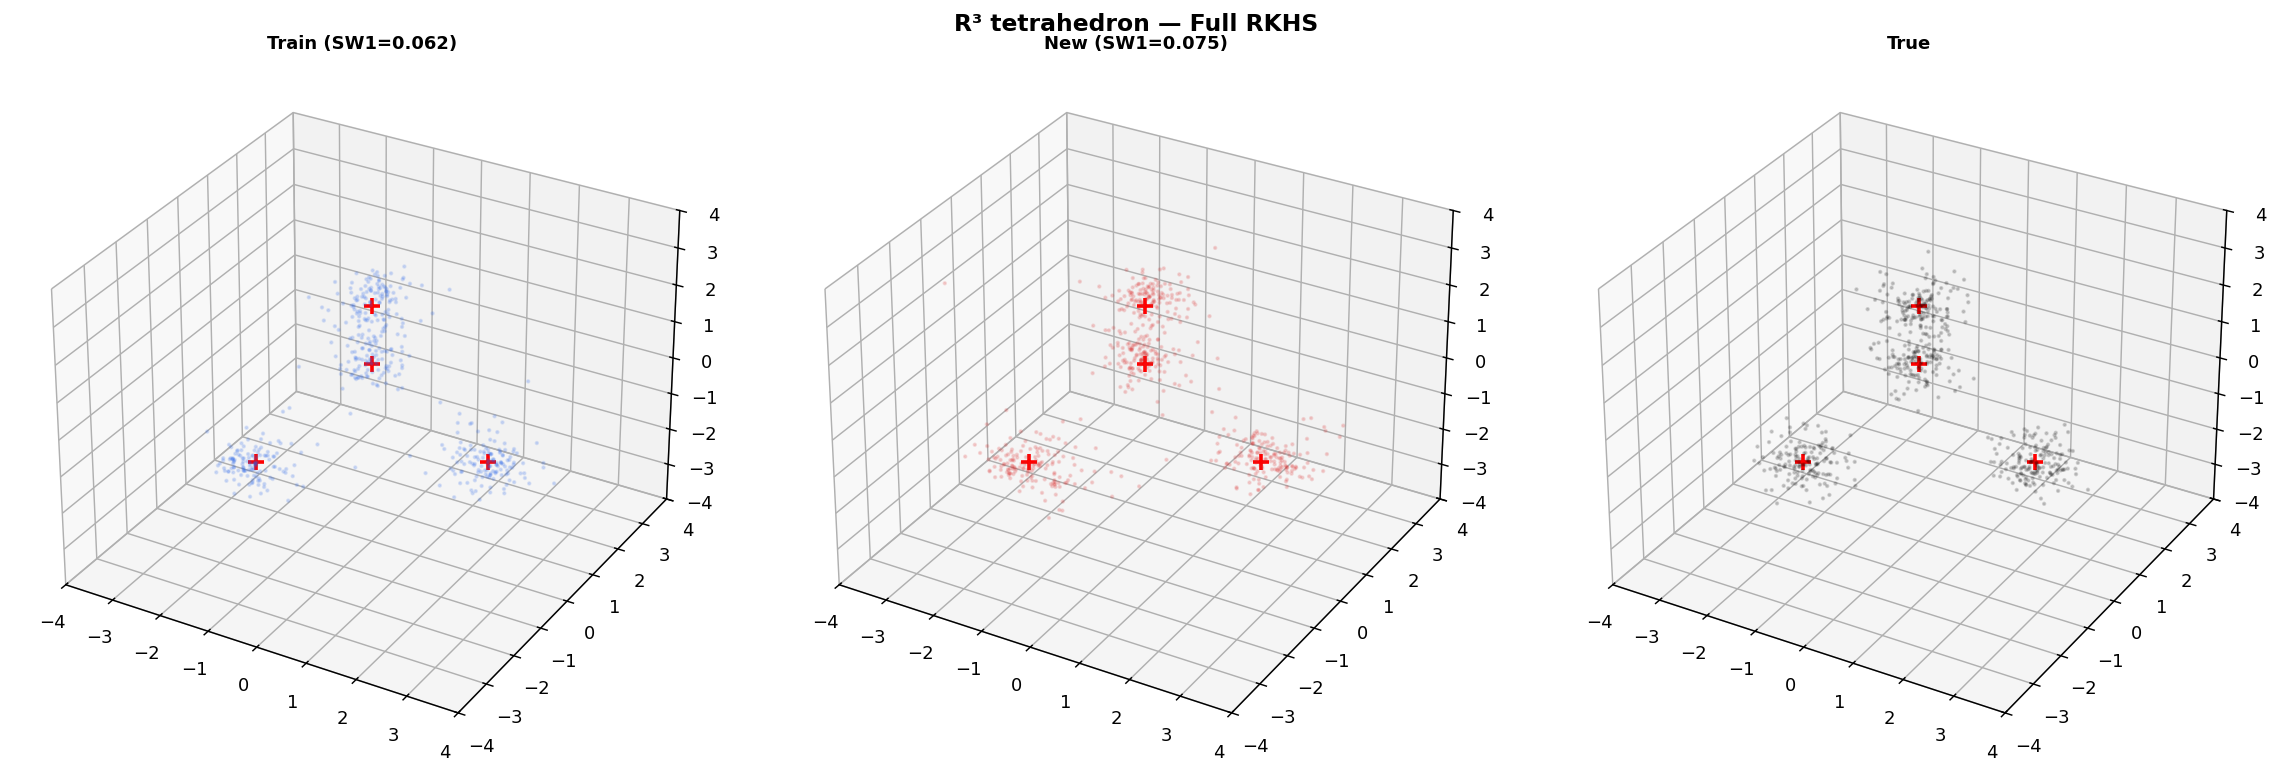

In [26]:
r3=2.5; tc=np.array([[0,0,r3],[r3*np.sqrt(8/9),0,-r3/3],[-r3*np.sqrt(2/9),r3*np.sqrt(2/3),-r3/3],[-r3*np.sqrt(2/9),-r3*np.sqrt(2/3),-r3/3]])
fig = plt.figure(figsize=(18,6))
for i,(data,title,color) in enumerate([
    (model_3d._fit_result['particles'],f'Train (SW1={sw_t3[-1]:.3f})','#2563eb'),
    (res_3d['particles'],f'New (SW1={sw_n3[-1]:.3f})','#dc2626'),
    (x_true_3d,'True','black')]):
    ax=fig.add_subplot(1,3,i+1,projection='3d')
    ax.scatter(data[:,0],data[:,1],data[:,2],s=2,alpha=0.15,c=color)
    for m in tc: ax.scatter(*m,s=80,c='red',marker='+',linewidths=2)
    ax.set_xlim(-4,4);ax.set_ylim(-4,4);ax.set_zlim(-4,4);ax.set_title(title,fontweight='bold',fontsize=10)
fig.suptitle('R³ tetrahedron — Full RKHS',fontweight='bold',fontsize=13)
plt.tight_layout();plt.show()

---
## 4. R² — Checkerboard 3×3

In [ ]:
csz,off=2.0,-3.0
cells=[(off+j*csz,off+i*csz) for i in range(3) for j in range(3) if (i+j)%2==0]
def sample_board(n):
    K=len(cells);s=np.zeros((n,2));lab=np.random.randint(0,K,n)
    for idx,(xl,yl) in enumerate(cells):
        m=lab==idx;s[m,0]=np.random.uniform(xl,xl+csz,m.sum());s[m,1]=np.random.uniform(yl,yl+csz,m.sum())
    return s
def draw_board(ax):
    for xl,yl in cells: ax.add_patch(Rectangle((xl,yl),csz,csz,fill=True,fc='green',alpha=0.1,ec='green',lw=1))
def pct_in(pts):
    ins=np.zeros(len(pts),dtype=bool)
    for xl,yl in cells: ins|=(pts[:,0]>=xl)&(pts[:,0]<=xl+csz)&(pts[:,1]>=yl)&(pts[:,1]<=yl+csz)
    return ins.mean()*100

N_train,N_data,N_new=400,400,350
X1_b=sample_board(N_data); x_true_b=sample_board(N_new)
model_b=EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-8, K_steps=80, N_src_max=10000, rescale=True, noise_level=1.5, n_inducing=100, q=0.5, q_final=0.1)
print('FIT:'); model_b.fit(np.random.randn(N_train,2), X1_b, n_iterations=50)
print('\nTRANSPORT:'); res_b=model_b.transport(np.random.randn(N_new,2), verbose=True)

FIT:
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=2.6271
  Iter 1: lift_ratio=0.585,  gamma=0.01000,  q=0.500,  sigma=2.627,  M=100
  Iter 2: lift_ratio=0.438,  gamma=0.00980,  q=0.492,  sigma=2.595,  M=100
  Iter 3: lift_ratio=0.356,  gamma=0.00959,  q=0.484,  sigma=2.561,  M=100
  Iter 4: lift_ratio=0.329,  gamma=0.00939,  q=0.476,  sigma=2.528,  M=100
  Iter 5: lift_ratio=0.311,  gamma=0.00918,  q=0.467,  sigma=2.496,  M=100
  Iter 6: lift_ratio=0.296,  gamma=0.00898,  q=0.459,  sigma=2.463,  M=100
  Iter 7: lift_ratio=0.284,  gamma=0.00878,  q=0.451,  sigma=2.430,  M=100
  Iter 8: lift_ratio=0.271,  gamma=0.00857,  q=0.443,  sigma=2.398,  M=100
  Iter 9: lift_ratio=0.257,  gamma=0.00837,  q=0.435,  sigma=2.365,  M=100
  Iter 10: lift_ratio=0.245,  gamma=0.00816,  q=0.427,  sigma=2.332,  M=100
  Iter 11: lift_ratio=0.233,  gamma=0.00796,  q=0.418,  sigma=2.298,  M=100
  Iter 12: lift_ratio=0.219,  gamma=0.00776,  q=0.410,  sigma=2.266,  M=100
  Iter 13: lift_ratio=0.203, 

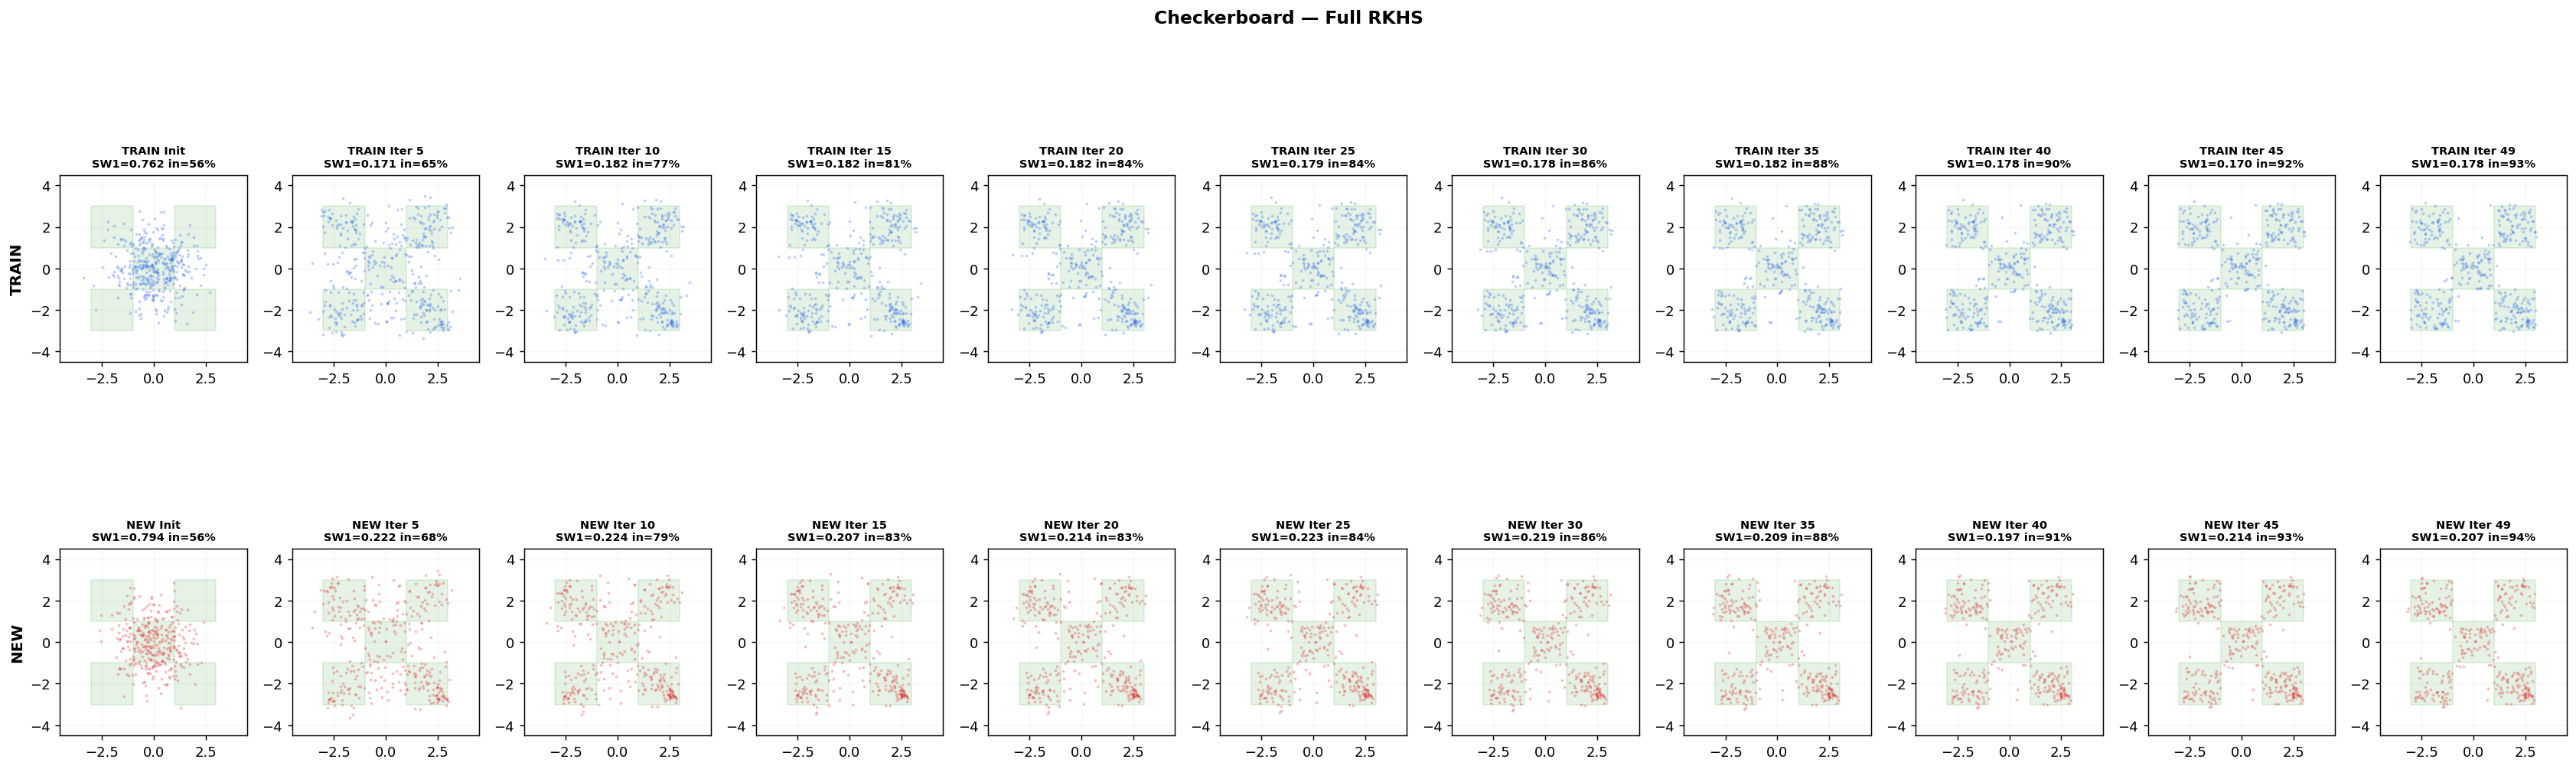

Train: SW1=0.182, in=94%
New:   SW1=0.200, in=93%


In [38]:
sw_tb=[sw1(s,x_true_b) for s in model_b._fit_result['snapshots']]
sw_nb=[sw1(s,x_true_b) for s in res_b['snapshots']]
fig,axes=plt.subplots(2,11,figsize=(26,9))
for col,it in enumerate([0,5,10,15,20,25,30,35,40,45,49]):
    for row,(sn,c,sv,lb) in enumerate([
        (model_b._fit_result['snapshots'],'#2563eb',sw_tb,'TRAIN'),
        (res_b['snapshots'],'#dc2626',sw_nb,'NEW')]):
        ax=axes[row,col]; draw_board(ax)
        ax.scatter(sn[it][:,0],sn[it][:,1],s=1.5,alpha=0.2,c=c)
        itl='Init' if it==0 else f'Iter {it}'; pi=pct_in(sn[it])
        ax.set_title(f'{lb} {itl}\nSW1={sv[it]:.3f} in={pi:.0f}%',fontsize=8,fontweight='bold')
        ax.set_xlim(-4.5,4.5);ax.set_ylim(-4.5,4.5);ax.set_aspect('equal');ax.grid(True,alpha=0.1)
        if col==0: ax.set_ylabel(lb,fontsize=11,fontweight='bold')
fig.suptitle('Checkerboard — Full RKHS',fontweight='bold',fontsize=13)
plt.tight_layout();plt.show()
print(f'Train: SW1={sw_tb[-1]:.3f}, in={pct_in(model_b._fit_result["particles"]):.0f}%')
print(f'New:   SW1={sw_nb[-1]:.3f}, in={pct_in(res_b["particles"]):.0f}%')

In [39]:
csz,off=2.0,-3.0
cells=[(off+j*csz,off+i*csz) for i in range(3) for j in range(3) if (i+j)%2==0]
def sample_board(n):
    K=len(cells);s=np.zeros((n,2));lab=np.random.randint(0,K,n)
    for idx,(xl,yl) in enumerate(cells):
        m=lab==idx;s[m,0]=np.random.uniform(xl,xl+csz,m.sum());s[m,1]=np.random.uniform(yl,yl+csz,m.sum())
    return s
def draw_board(ax):
    for xl,yl in cells: ax.add_patch(Rectangle((xl,yl),csz,csz,fill=True,fc='green',alpha=0.1,ec='green',lw=1))
def pct_in(pts):
    ins=np.zeros(len(pts),dtype=bool)
    for xl,yl in cells: ins|=(pts[:,0]>=xl)&(pts[:,0]<=xl+csz)&(pts[:,1]>=yl)&(pts[:,1]<=yl+csz)
    return ins.mean()*100

N_train,N_data,N_new=400,400,350
X1_b=sample_board(N_data); x_true_b=sample_board(N_new)
model_b=EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-8, K_steps=80, N_src_max=10000, rescale=False, noise_level=1.5, n_inducing=100, q=0.5, q_final=0.1)
print('FIT:'); model_b.fit(np.random.randn(N_train,2), X1_b, n_iterations=50)
print('\nTRANSPORT:'); res_b=model_b.transport(np.random.randn(N_new,2), verbose=True)

FIT:
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=2.6213
  Iter 1: lift_ratio=0.591,  gamma=0.01000,  q=0.500,  sigma=2.621,  M=100
  Iter 2: lift_ratio=0.499,  gamma=0.00980,  q=0.492,  sigma=2.588,  M=100
  Iter 3: lift_ratio=0.427,  gamma=0.00959,  q=0.484,  sigma=2.556,  M=100
  Iter 4: lift_ratio=0.387,  gamma=0.00939,  q=0.476,  sigma=2.523,  M=100
  Iter 5: lift_ratio=0.359,  gamma=0.00918,  q=0.467,  sigma=2.490,  M=100
  Iter 6: lift_ratio=0.343,  gamma=0.00898,  q=0.459,  sigma=2.457,  M=100
  Iter 7: lift_ratio=0.330,  gamma=0.00878,  q=0.451,  sigma=2.423,  M=100
  Iter 8: lift_ratio=0.320,  gamma=0.00857,  q=0.443,  sigma=2.389,  M=100
  Iter 9: lift_ratio=0.311,  gamma=0.00837,  q=0.435,  sigma=2.357,  M=100
  Iter 10: lift_ratio=0.300,  gamma=0.00816,  q=0.427,  sigma=2.324,  M=100
  Iter 11: lift_ratio=0.288,  gamma=0.00796,  q=0.418,  sigma=2.290,  M=100
  Iter 12: lift_ratio=0.272,  gamma=0.00776,  q=0.410,  sigma=2.257,  M=100
  Iter 13: lift_ratio=0.258, 

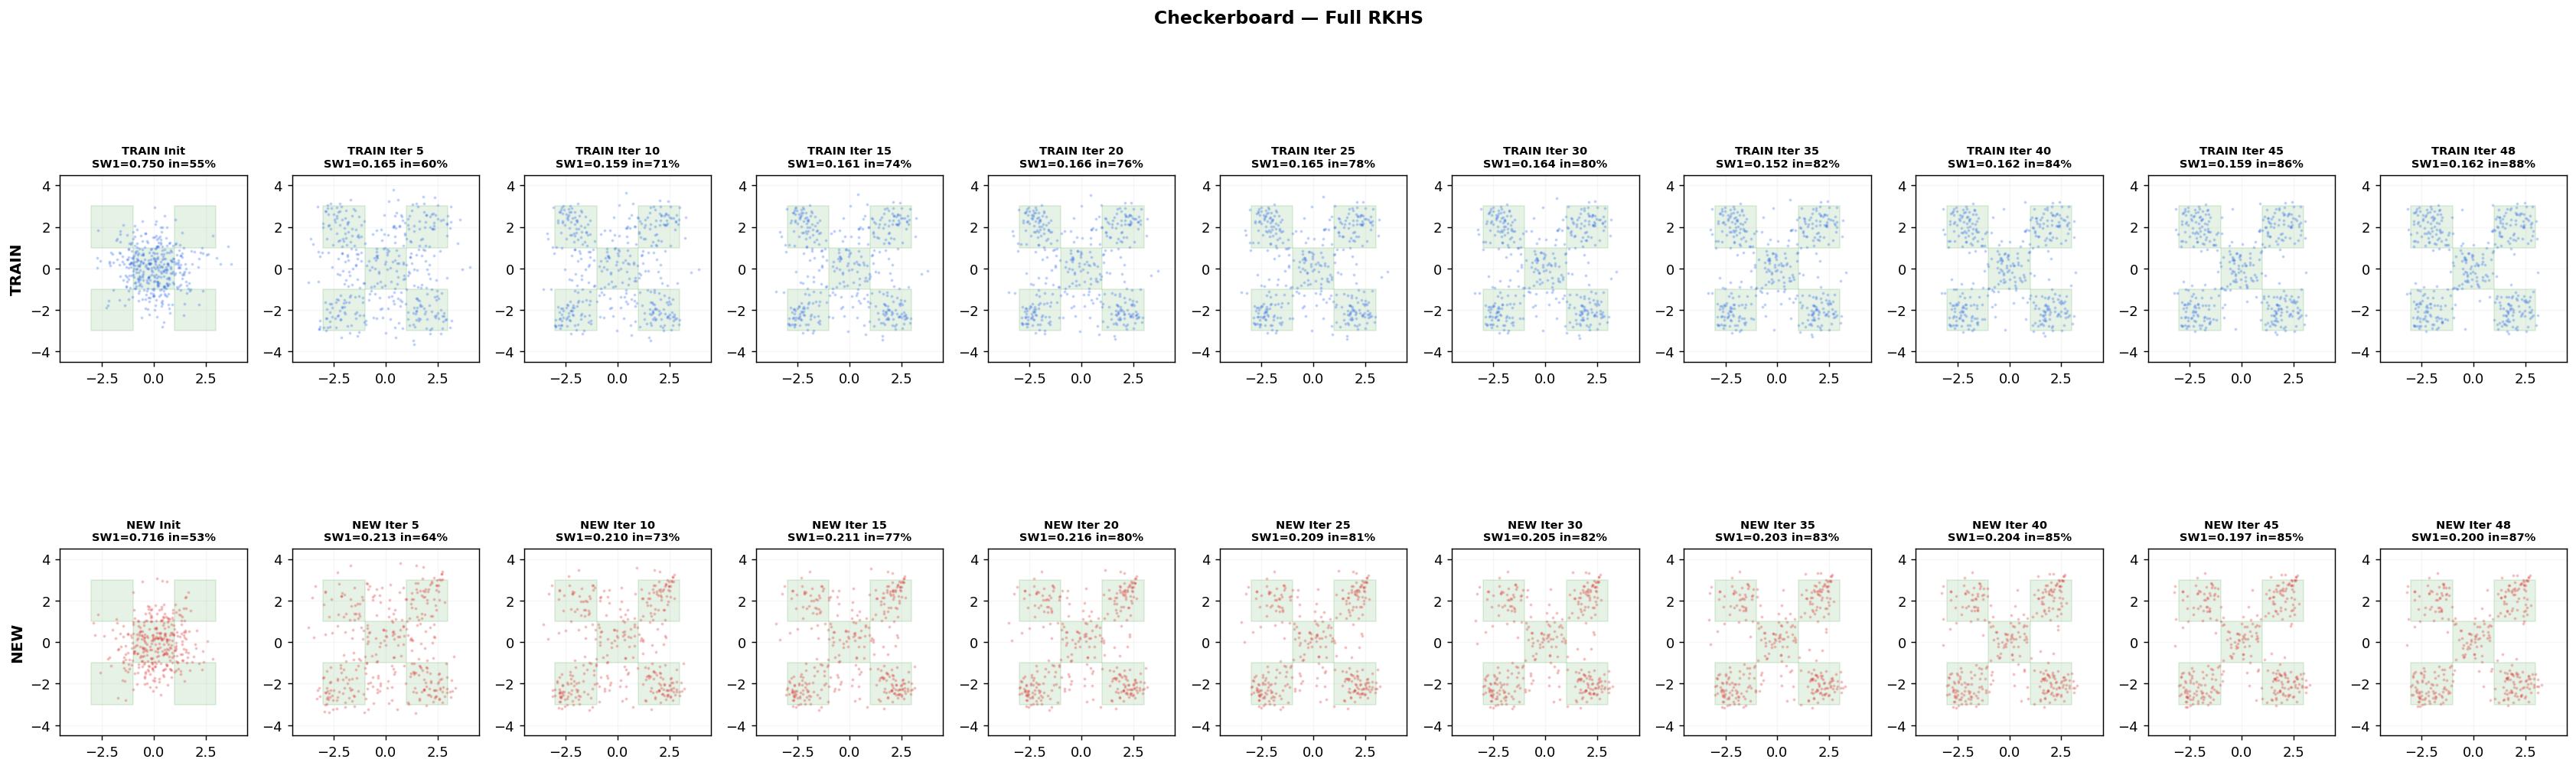

Train: SW1=0.159, in=90%
New:   SW1=0.211, in=88%


In [40]:
sw_tb=[sw1(s,x_true_b) for s in model_b._fit_result['snapshots']]
sw_nb=[sw1(s,x_true_b) for s in res_b['snapshots']]
fig,axes=plt.subplots(2,11,figsize=(26,9))
for col,it in enumerate([0,5,10,15,20,25,30,35,40,45,48]):
    for row,(sn,c,sv,lb) in enumerate([
        (model_b._fit_result['snapshots'],'#2563eb',sw_tb,'TRAIN'),
        (res_b['snapshots'],'#dc2626',sw_nb,'NEW')]):
        ax=axes[row,col]; draw_board(ax)
        ax.scatter(sn[it][:,0],sn[it][:,1],s=1.5,alpha=0.2,c=c)
        itl='Init' if it==0 else f'Iter {it}'; pi=pct_in(sn[it])
        ax.set_title(f'{lb} {itl}\nSW1={sv[it]:.3f} in={pi:.0f}%',fontsize=8,fontweight='bold')
        ax.set_xlim(-4.5,4.5);ax.set_ylim(-4.5,4.5);ax.set_aspect('equal');ax.grid(True,alpha=0.1)
        if col==0: ax.set_ylabel(lb,fontsize=11,fontweight='bold')
fig.suptitle('Checkerboard — Full RKHS',fontweight='bold',fontsize=13)
plt.tight_layout();plt.show()
print(f'Train: SW1={sw_tb[-1]:.3f}, in={pct_in(model_b._fit_result["particles"]):.0f}%')
print(f'New:   SW1={sw_nb[-1]:.3f}, in={pct_in(res_b["particles"]):.0f}%')

---
## 5. R² — Ring of 8

In [50]:
N_train,N_data,N_new=500,300,600
X1_r=distributions.ring_2d(N_data,K=8,r=3.0,sigma=0.3)
x_true_r=distributions.ring_2d(N_new,K=8,r=3.0,sigma=0.3)
model_r=EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-9, K_steps=80, N_src_max=10000, n_inducing=100, q=0.5, q_final=0.1)
print('FIT:'); model_r.fit(np.random.randn(N_train,2),X1_r,n_iterations=16)
print('\nTRANSPORT:'); res_r=model_r.transport(np.random.randn(N_new,2),verbose=True)

FIT:
  Iter 1: lift_ratio=0.685,  gamma=0.01000,  q=0.500,  sigma=2.592,  M=100
  Iter 2: lift_ratio=0.686,  gamma=0.00933,  q=0.473,  sigma=3.698,  M=100
  Iter 3: lift_ratio=0.426,  gamma=0.00867,  q=0.447,  sigma=3.841,  M=100
  Iter 4: lift_ratio=0.397,  gamma=0.00800,  q=0.420,  sigma=3.679,  M=100
  Iter 5: lift_ratio=0.368,  gamma=0.00733,  q=0.393,  sigma=3.476,  M=100
  Iter 6: lift_ratio=0.319,  gamma=0.00667,  q=0.367,  sigma=3.253,  M=100
  Iter 7: lift_ratio=0.220,  gamma=0.00600,  q=0.340,  sigma=3.025,  M=100
  Iter 8: lift_ratio=0.102,  gamma=0.00533,  q=0.313,  sigma=2.798,  M=100
  Iter 9: lift_ratio=0.071,  gamma=0.00467,  q=0.287,  sigma=2.580,  M=100
  Iter 10: lift_ratio=0.094,  gamma=0.00400,  q=0.260,  sigma=2.375,  M=100
  Iter 11: lift_ratio=0.119,  gamma=0.00333,  q=0.233,  sigma=2.188,  M=100
  Iter 12: lift_ratio=0.150,  gamma=0.00267,  q=0.207,  sigma=2.007,  M=100
  Iter 13: lift_ratio=0.188,  gamma=0.00200,  q=0.180,  sigma=1.814,  M=100
  Iter 14: lift_

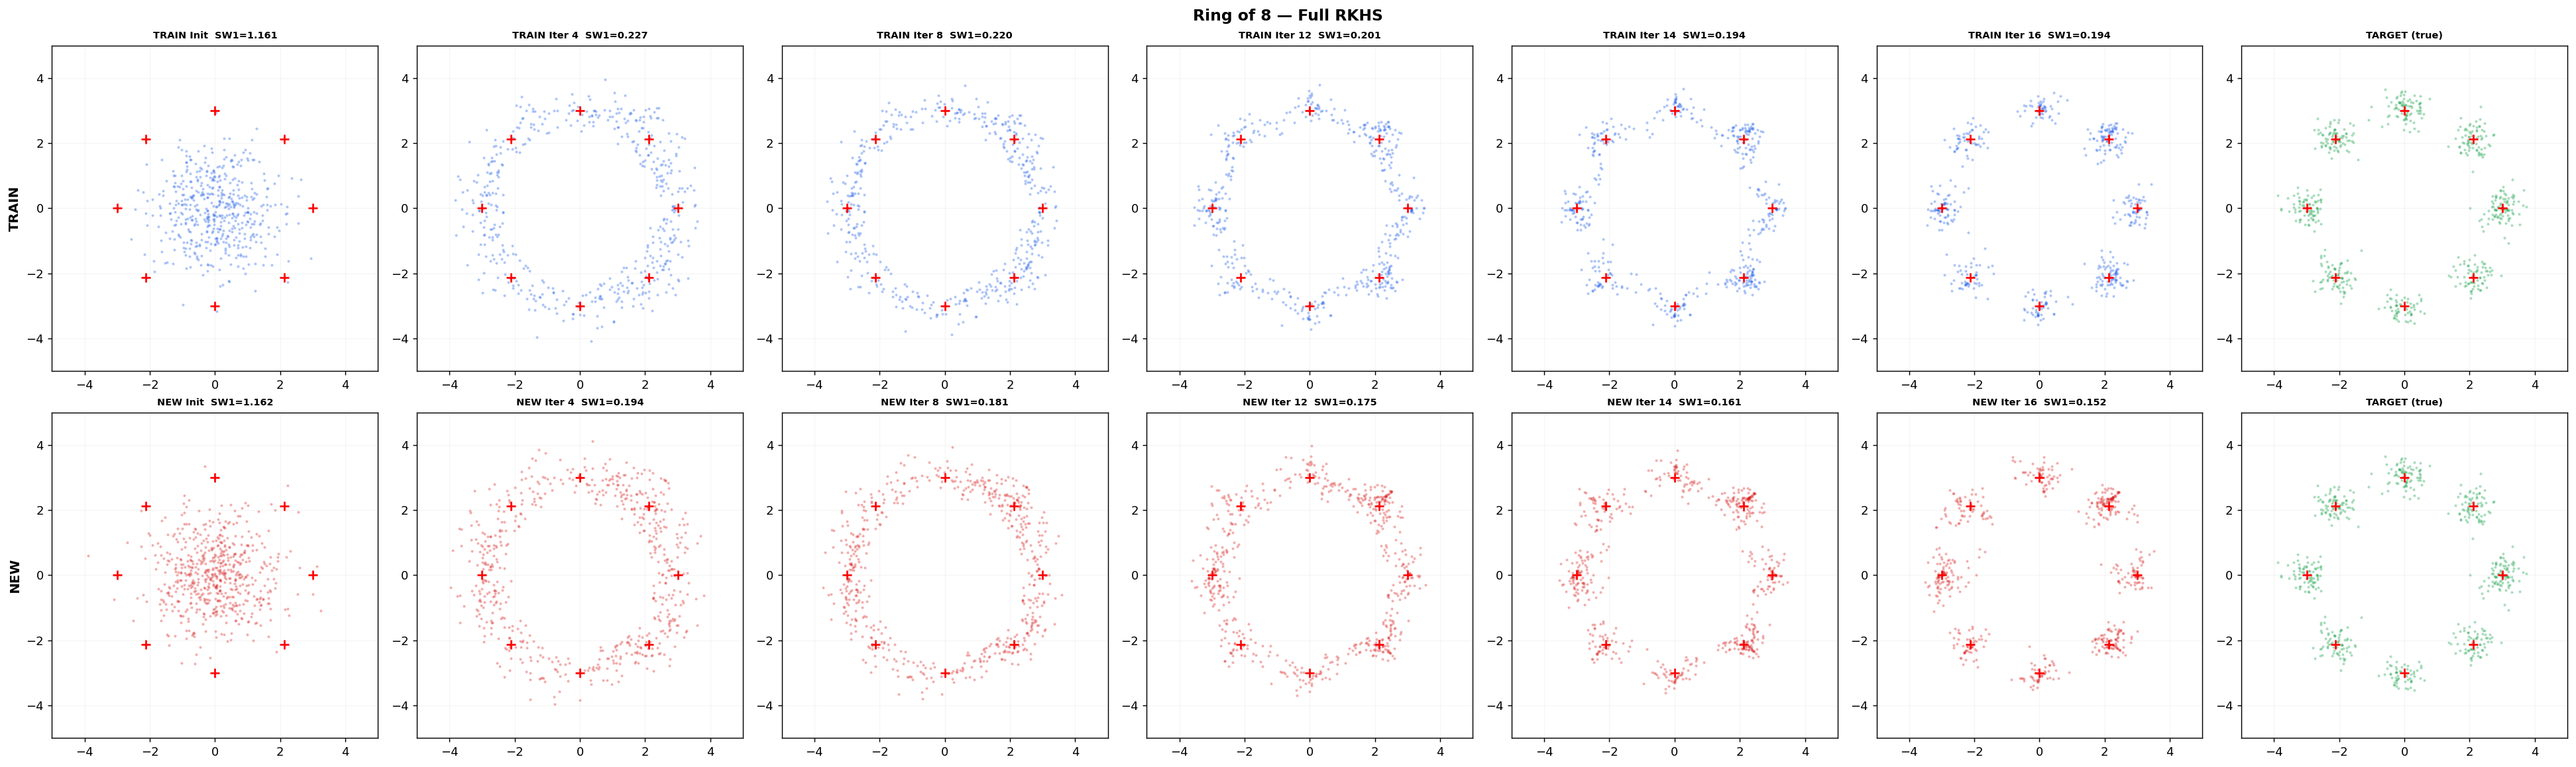

In [51]:
sw_tr=[sw1(s,x_true_r) for s in model_r._fit_result['snapshots']]
sw_nr=[sw1(s,x_true_r) for s in res_r['snapshots']]
rc=3.0*np.column_stack([np.cos(np.linspace(0,2*np.pi,8,endpoint=False)),np.sin(np.linspace(0,2*np.pi,8,endpoint=False))])
fig,axes=plt.subplots(2,7,figsize=(30,9))
for col,it in enumerate([0, 4, 8, 12, 14, 16]):
    for row,(sn,c,sv,lb) in enumerate([
        (model_r._fit_result['snapshots'],'#2563eb',sw_tr,'TRAIN'),
        (res_r['snapshots'],'#dc2626',sw_nr,'NEW')]):
        ax=axes[row,col]; ax.scatter(sn[it][:,0],sn[it][:,1],s=2,alpha=0.25,c=c)
        for cc in rc: ax.plot(cc[0],cc[1],'r+',ms=8,mew=1.5)
        itl='Init' if it==0 else f'Iter {it}'
        ax.set_title(f'{lb} {itl}  SW1={sv[it]:.3f}',fontsize=8,fontweight='bold')
        ax.set_xlim(-5,5);ax.set_ylim(-5,5);ax.set_aspect('equal');ax.grid(True,alpha=0.1)
        if col==0: ax.set_ylabel(lb,fontsize=11,fontweight='bold')
fig.suptitle('Ring of 8 — Full RKHS',fontweight='bold',fontsize=13)

for row in range(2):
    ax=axes[row,6]
    ax.scatter(x_true_r[:,0],x_true_r[:,1],s=2,alpha=0.25,c='#16a34a')
    for cc in rc: ax.plot(cc[0],cc[1],'r+',ms=8,mew=1.5)
    ax.set_title('TARGET (true)',fontsize=8,fontweight='bold')
    ax.set_xlim(-5,5);ax.set_ylim(-5,5);ax.set_aspect('equal');ax.grid(True,alpha=0.1)

fig.suptitle('Ring of 8 — Full RKHS',fontweight='bold',fontsize=13)
plt.tight_layout();plt.show()

# Two moons.

In [2]:
N_train, N_data, N_new = 500, 250, 600
X1_2d = distributions.two_moons(N_data)
x_true_2d = distributions.two_moons(N_new)

model_2d = EmbeddedInterpolants(sigma_k=None, gamma=0.01, gamma_final=1e-9, K_steps=80, N_src_max=10000, n_inducing=100, noise_level=1.0, q=0.5, q_final=0.1, rescale=False)
print('FIT:'); model_2d.fit(np.random.randn(N_train,2), X1_2d, n_iterations=20)
print('\nTRANSPORT:'); res_2d = model_2d.transport(np.random.randn(N_new,2), verbose=True)

sw_t2 = [sw1(s, x_true_2d) for s in model_2d._fit_result['snapshots']]
sw_n2 = [sw1(s, x_true_2d) for s in res_2d['snapshots']]
print(f'\nTrain SW1={sw_t2[-1]:.3f}, New SW1={sw_n2[-1]:.3f}')

FIT:
  Bandwidth (quantile, decaying q=0.5->0.1): sigma_init=1.6294
  Iter 1: lift_ratio=0.532,  gamma=0.01000,  q=0.500,  sigma=1.629,  M=100
  Iter 2: lift_ratio=0.476,  gamma=0.00947,  q=0.479,  sigma=1.583,  M=100
  Iter 3: lift_ratio=0.431,  gamma=0.00895,  q=0.458,  sigma=1.537,  M=100
  Iter 4: lift_ratio=0.409,  gamma=0.00842,  q=0.437,  sigma=1.491,  M=100
  Iter 5: lift_ratio=0.402,  gamma=0.00789,  q=0.416,  sigma=1.444,  M=100
  Iter 6: lift_ratio=0.399,  gamma=0.00737,  q=0.395,  sigma=1.398,  M=100
  Iter 7: lift_ratio=0.390,  gamma=0.00684,  q=0.374,  sigma=1.351,  M=100
  Iter 8: lift_ratio=0.384,  gamma=0.00632,  q=0.353,  sigma=1.303,  M=100
  Iter 9: lift_ratio=0.377,  gamma=0.00579,  q=0.332,  sigma=1.254,  M=100
  Iter 10: lift_ratio=0.372,  gamma=0.00526,  q=0.311,  sigma=1.205,  M=100
  Iter 11: lift_ratio=0.368,  gamma=0.00474,  q=0.289,  sigma=1.153,  M=100
  Iter 12: lift_ratio=0.366,  gamma=0.00421,  q=0.268,  sigma=1.101,  M=100
  Iter 13: lift_ratio=0.363, 

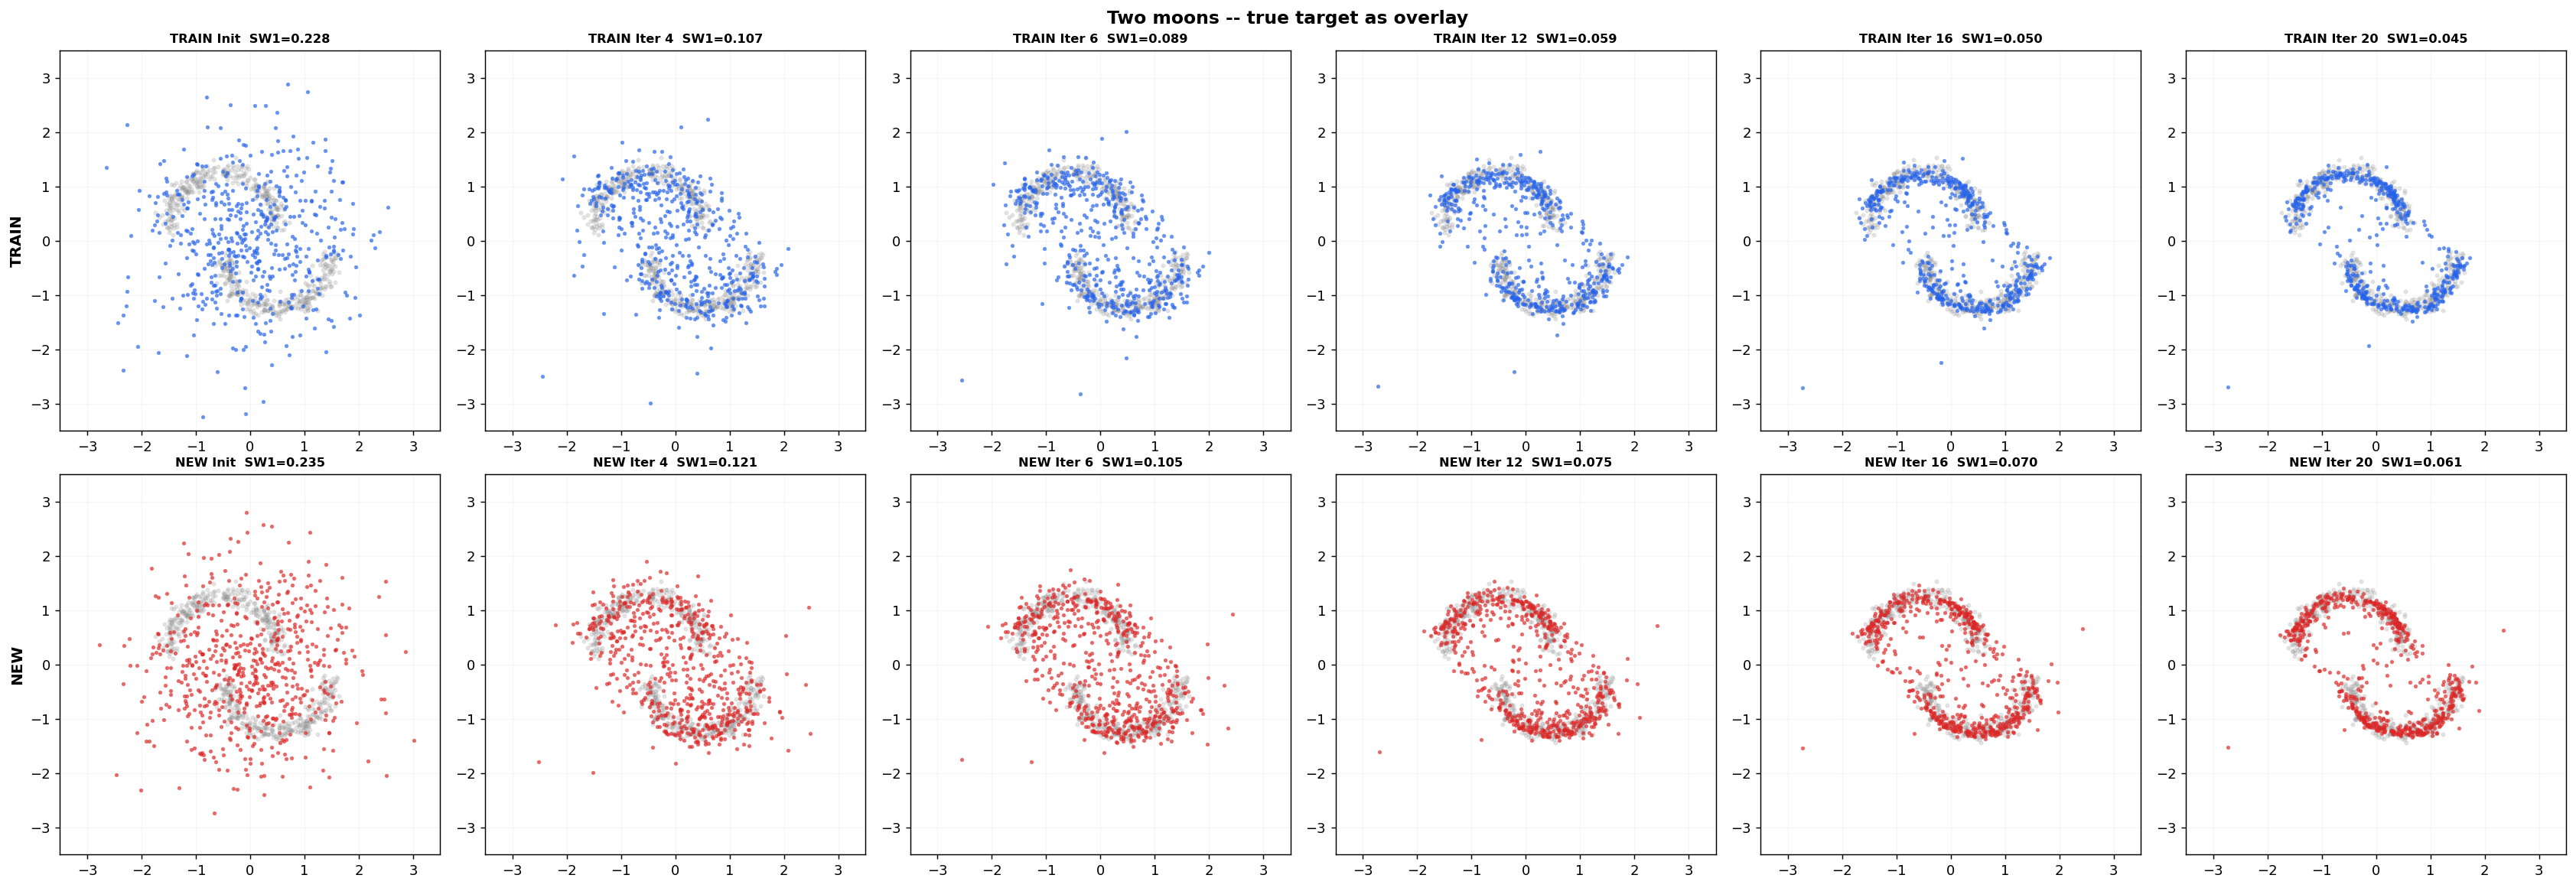

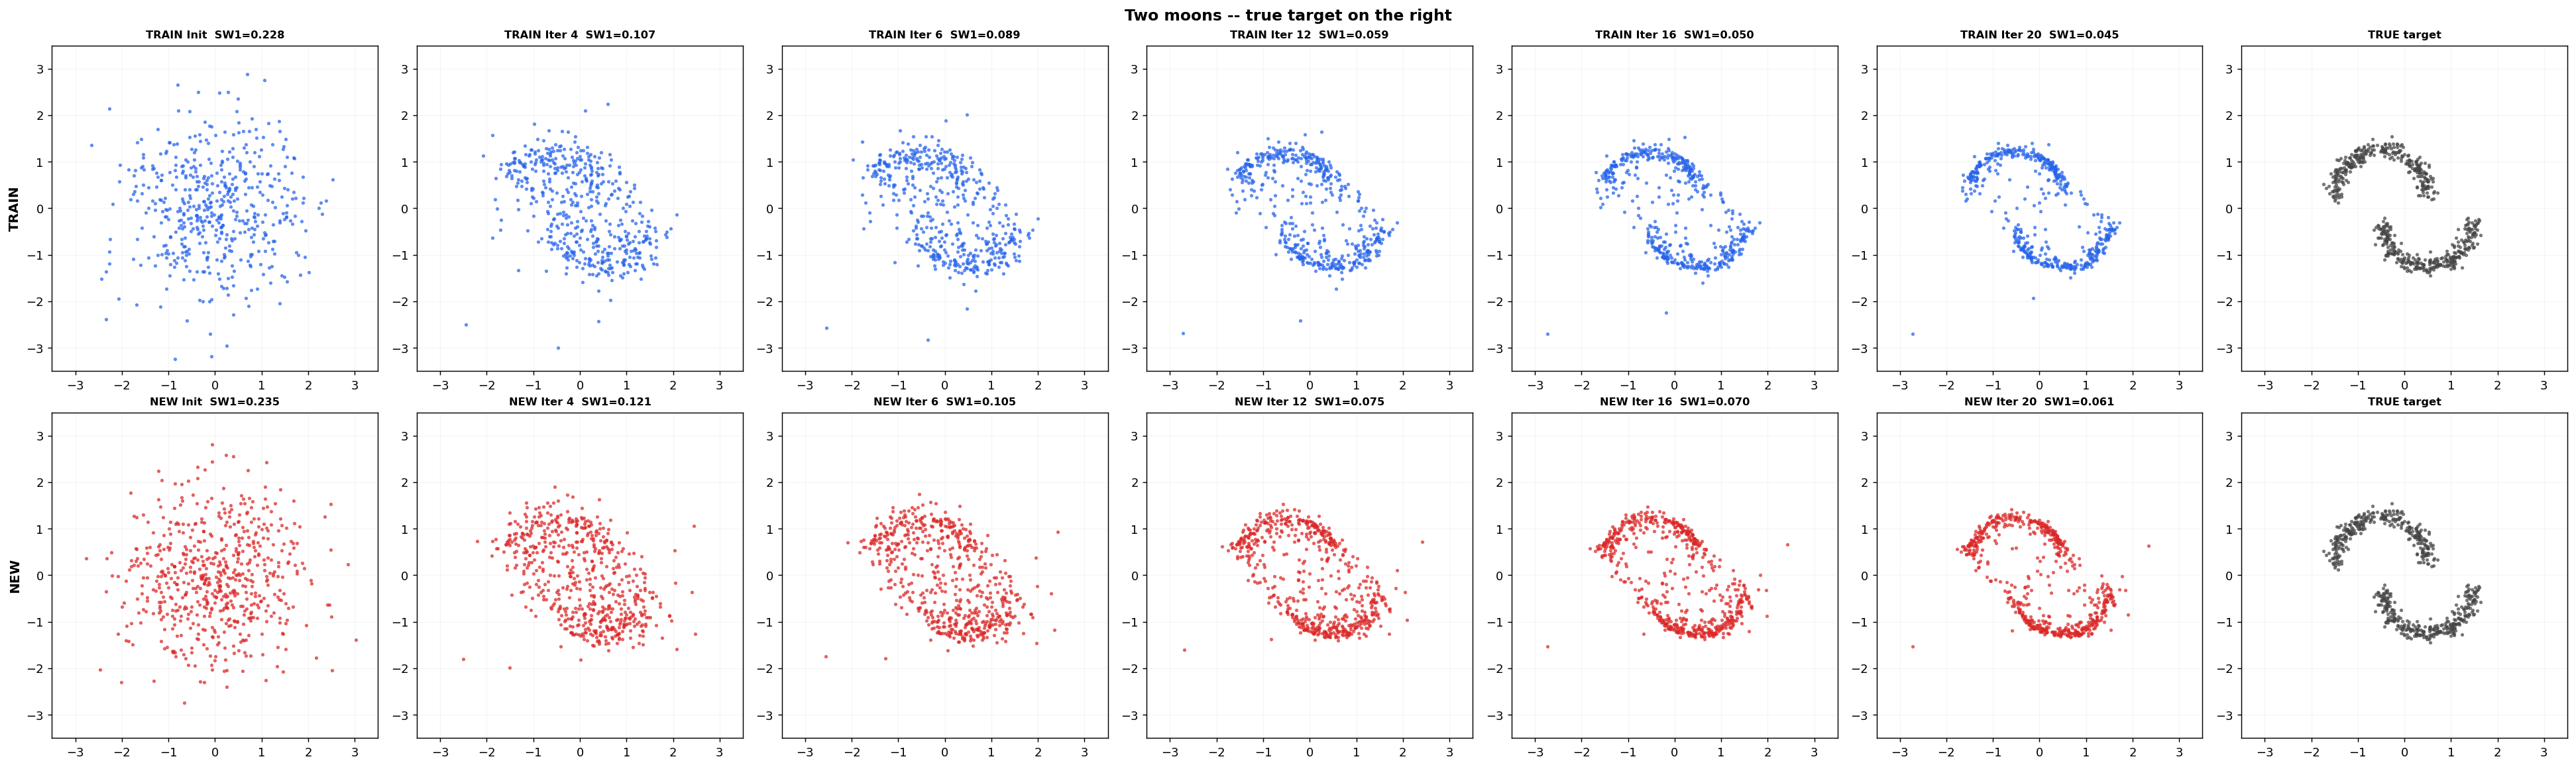

In [4]:
XL, YL = (-3.5, 3.5), (-3.5, 3.5)


# =============================================================================
# VERSION A -- true target as light gray OVERLAY behind every snapshot
# =============================================================================
iters_A = [0, 4, 6, 12, 16, 20]                # 6 columns, 6 iterations
fig, axes = plt.subplots(2, len(iters_A), figsize=(26, 9))

for col, it in enumerate(iters_A):
    for row, (sn, c, sv, lb) in enumerate([
        (model_2d._fit_result['snapshots'], '#2563eb', sw_t2, 'TRAIN'),
        (res_2d['snapshots'],                '#dc2626', sw_n2, 'NEW'),
    ]):
        ax = axes[row, col]
        # true target as faint background
        ax.scatter(x_true_2d[:, 0], x_true_2d[:, 1],
                   s=6, alpha=0.18, c='#888888', zorder=1, label='true')
        # snapshot on top
        ax.scatter(sn[it][:, 0], sn[it][:, 1],
                   s=4, alpha=0.55, c=c, zorder=2)
        itl = 'Init' if it == 0 else f'Iter {it}'
        ax.set_title(f'{lb} {itl}  SW1={sv[it]:.3f}',
                     fontsize=9, fontweight='bold')
        ax.set_xlim(*XL); ax.set_ylim(*YL)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.1)
        if col == 0:
            ax.set_ylabel(lb, fontsize=11, fontweight='bold')

fig.suptitle('Two moons -- true target as overlay',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


# =============================================================================
# VERSION B -- true target as a separate panel on the right
# =============================================================================
iters_B = [0, 4, 6, 12, 16, 20]              # 6 snapshot iterations
n_cols  = len(iters_B) + 1                   # +1 for the true-target column
fig, axes = plt.subplots(2, n_cols, figsize=(30, 9))

for col, it in enumerate(iters_B):
    for row, (sn, c, sv, lb) in enumerate([
        (model_2d._fit_result['snapshots'], '#2563eb', sw_t2, 'TRAIN'),
        (res_2d['snapshots'],                '#dc2626', sw_n2, 'NEW'),
    ]):
        ax = axes[row, col]
        ax.scatter(sn[it][:, 0], sn[it][:, 1],
                   s=4, alpha=0.6, c=c)
        itl = 'Init' if it == 0 else f'Iter {it}'
        ax.set_title(f'{lb} {itl}  SW1={sv[it]:.3f}',
                     fontsize=9, fontweight='bold')
        ax.set_xlim(*XL); ax.set_ylim(*YL)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.1)
        if col == 0:
            ax.set_ylabel(lb, fontsize=11, fontweight='bold')

# right column -- true target, repeated on both rows
for row in (0, 1):
    ax = axes[row, -1]
    ax.scatter(x_true_2d[:, 0], x_true_2d[:, 1],
               s=4, alpha=0.6, c='#444444')
    ax.set_title('TRUE target', fontsize=9, fontweight='bold')
    ax.set_xlim(*XL); ax.set_ylim(*YL)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.1)

fig.suptitle('Two moons -- true target on the right',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

---
## 6. Summary

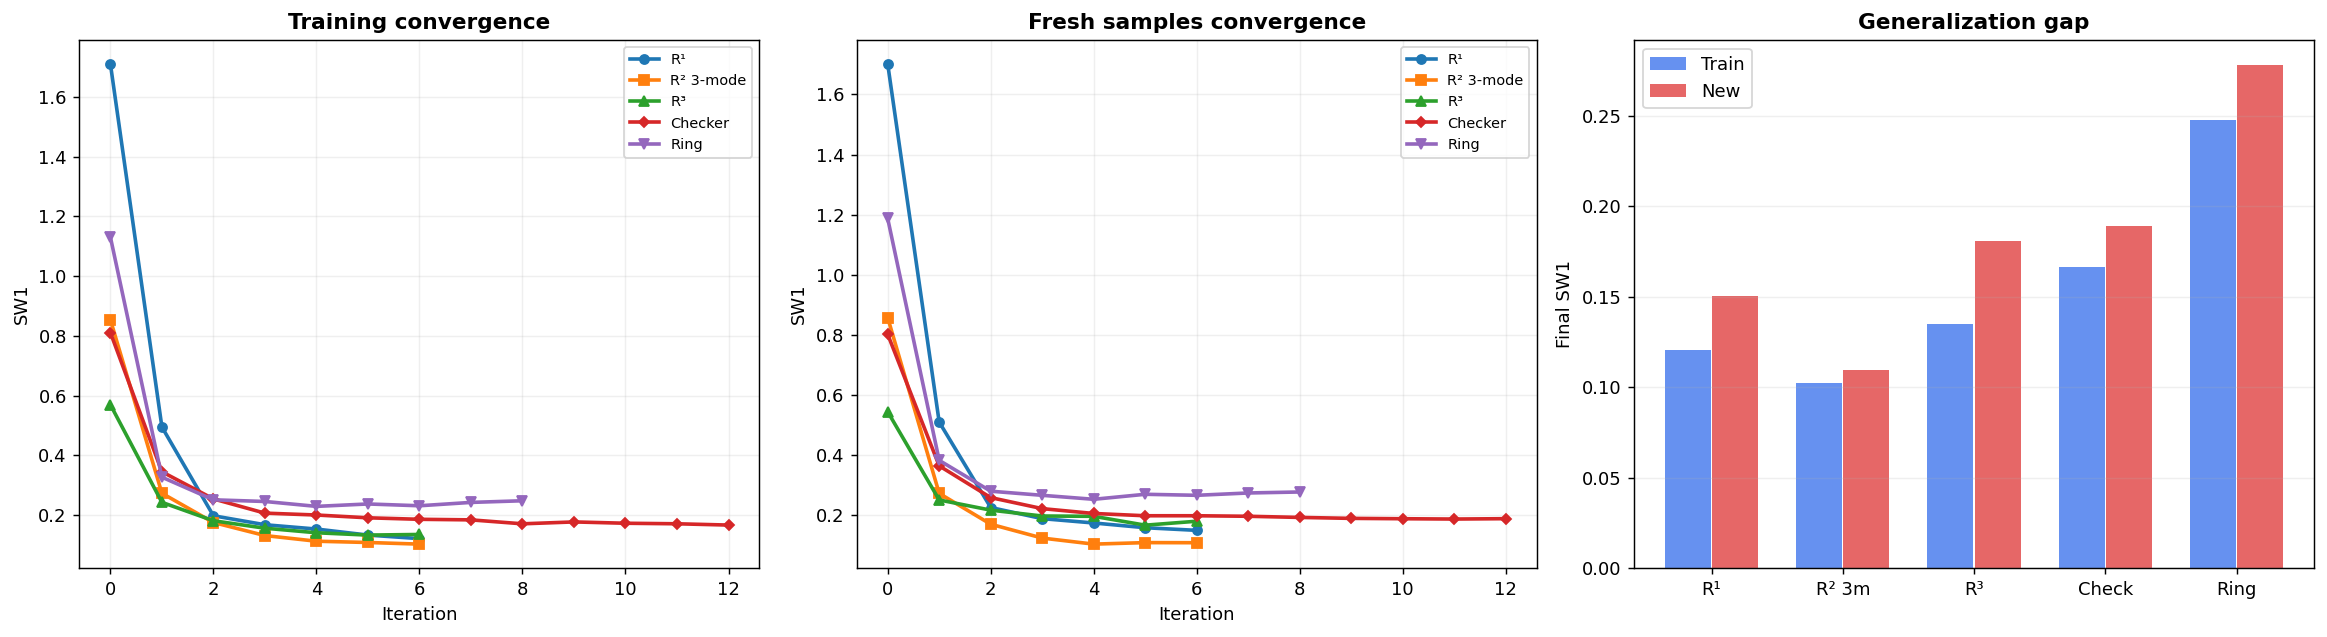

  R¹     train=0.121 new=0.150 gap=+0.030
  R² 3m  train=0.102 new=0.109 gap=+0.007
  R³     train=0.135 new=0.181 gap=+0.046
  Check  train=0.166 new=0.189 gap=+0.023
  Ring   train=0.248 new=0.278 gap=+0.030


In [51]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
ax=axes[0]
ax.plot(sw_t1,'o-',lw=2,ms=5,label='R¹');ax.plot(sw_t2,'s-',lw=2,ms=5,label='R² 3-mode')
ax.plot(sw_t3,'^-',lw=2,ms=5,label='R³');ax.plot(sw_tb,'D-',lw=2,ms=4,label='Checker')
ax.plot(sw_tr,'v-',lw=2,ms=5,label='Ring')
ax.set_xlabel('Iteration');ax.set_ylabel('SW1');ax.set_title('Training convergence',fontweight='bold')
ax.legend(fontsize=8);ax.grid(True,alpha=0.2)
ax=axes[1]
ax.plot(sw_n1,'o-',lw=2,ms=5,label='R¹');ax.plot(sw_n2,'s-',lw=2,ms=5,label='R² 3-mode')
ax.plot(sw_n3,'^-',lw=2,ms=5,label='R³');ax.plot(sw_nb,'D-',lw=2,ms=4,label='Checker')
ax.plot(sw_nr,'v-',lw=2,ms=5,label='Ring')
ax.set_xlabel('Iteration');ax.set_ylabel('SW1');ax.set_title('Fresh samples convergence',fontweight='bold')
ax.legend(fontsize=8);ax.grid(True,alpha=0.2)
ax=axes[2]
names=['R¹','R² 3m','R³','Check','Ring']
tf=[sw_t1[-1],sw_t2[-1],sw_t3[-1],sw_tb[-1],sw_tr[-1]]
nf=[sw_n1[-1],sw_n2[-1],sw_n3[-1],sw_nb[-1],sw_nr[-1]]
x_pos=np.arange(5)
ax.bar(x_pos-0.18,tf,0.35,color='#2563eb',alpha=0.7,label='Train')
ax.bar(x_pos+0.18,nf,0.35,color='#dc2626',alpha=0.7,label='New')
ax.set_xticks(x_pos);ax.set_xticklabels(names)
ax.set_ylabel('Final SW1');ax.set_title('Generalization gap',fontweight='bold')
ax.legend();ax.grid(True,alpha=0.2,axis='y')
plt.tight_layout();plt.show()
for name,tr,nw in zip(names,tf,nf): print(f'  {name:6s} train={tr:.3f} new={nw:.3f} gap={nw-tr:+.3f}')